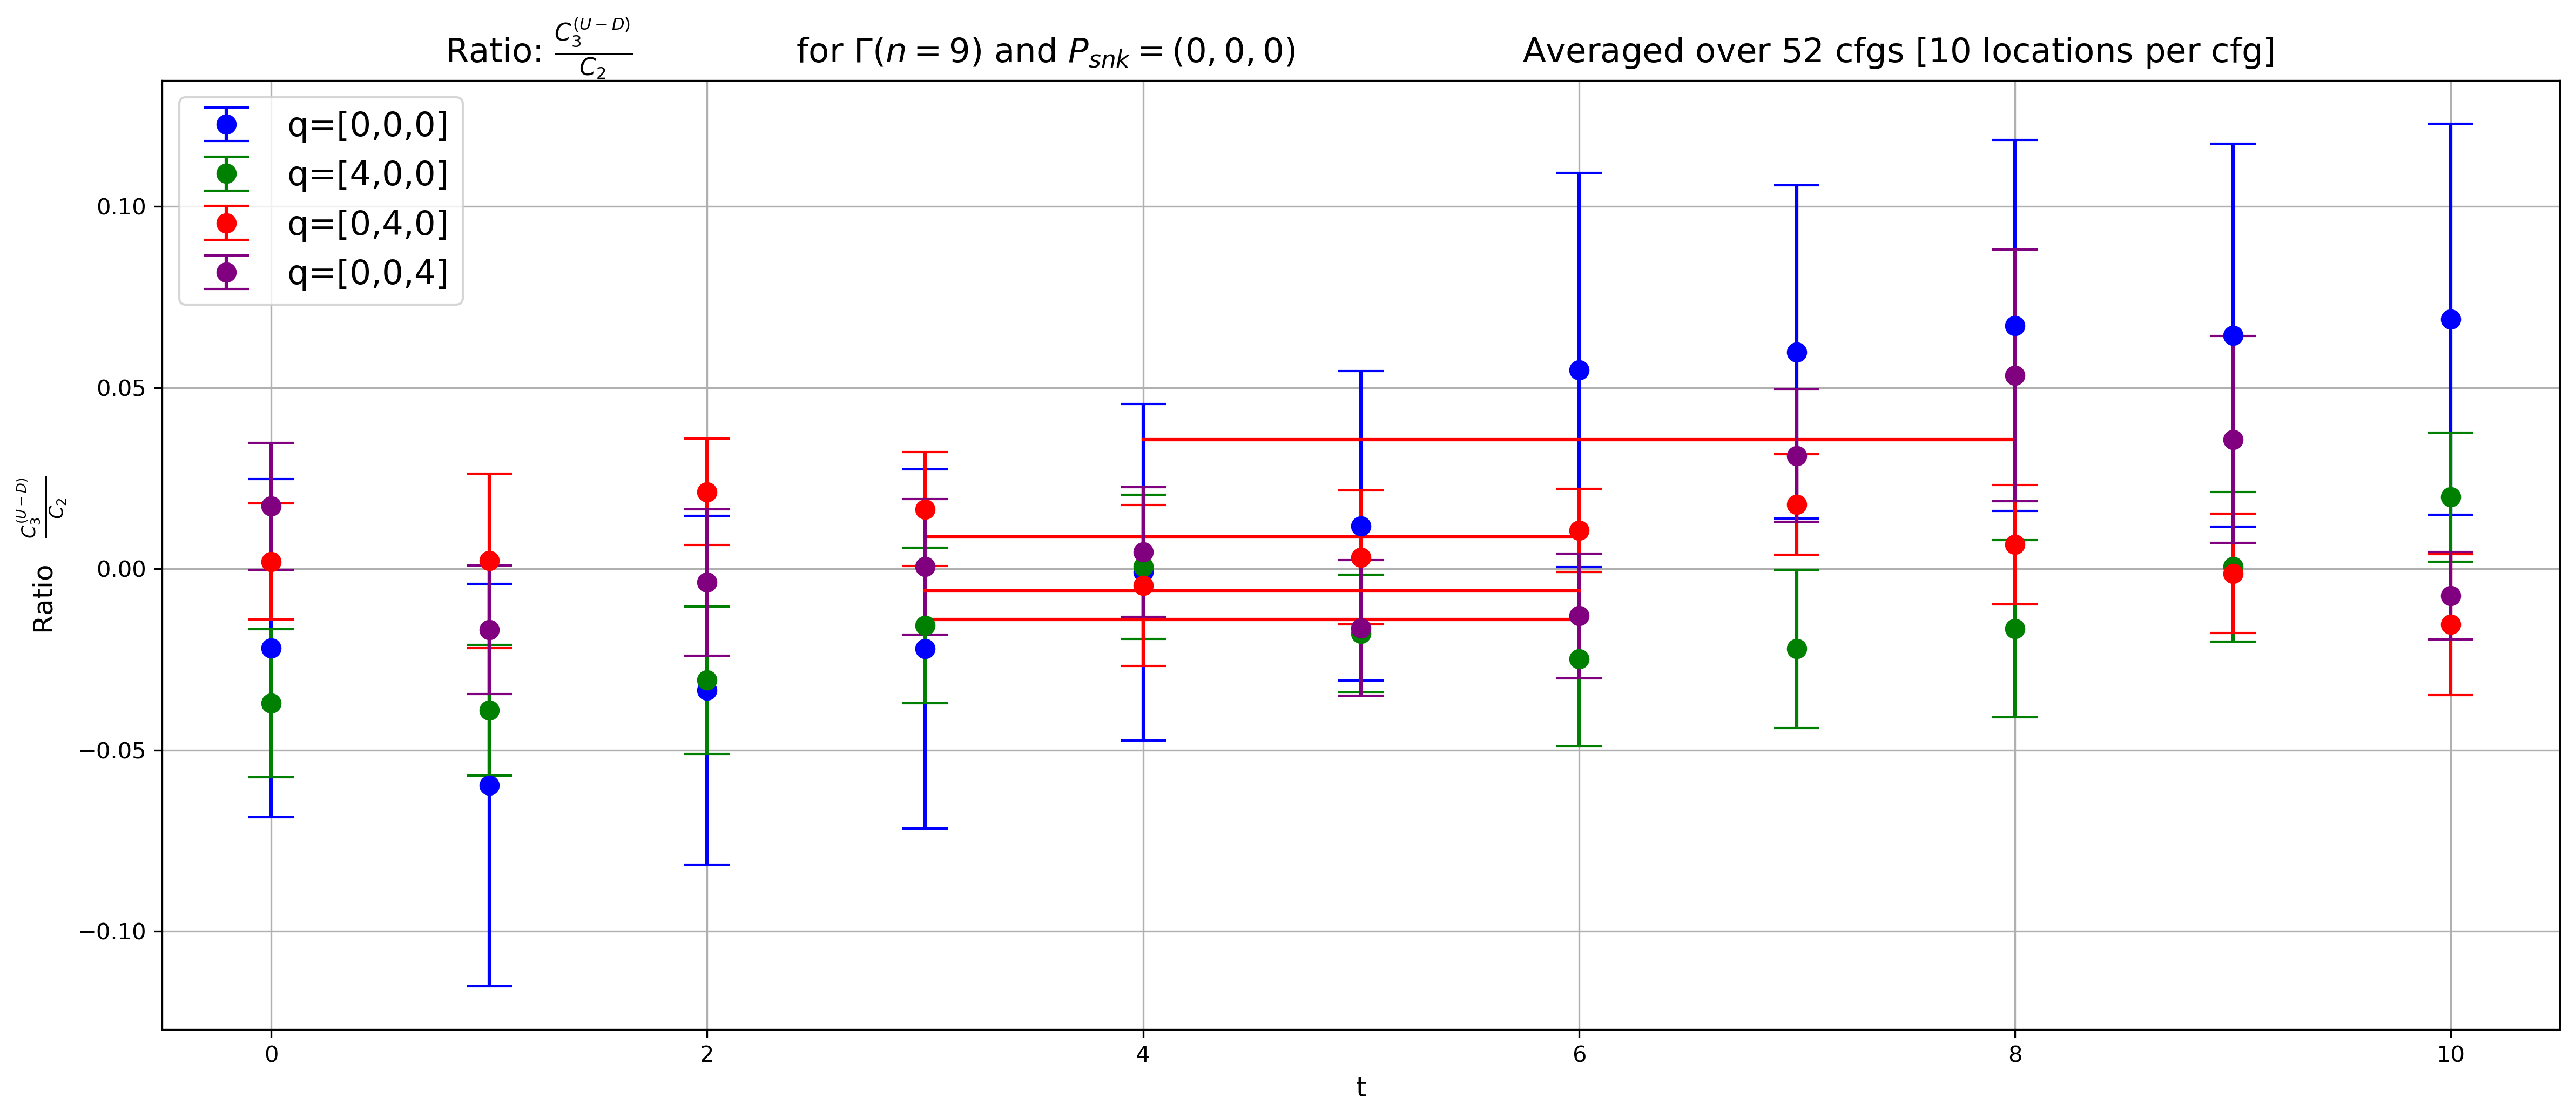

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from contextlib import ExitStack

#lattice size a
a = 0.114

# plateau_fit
def plateau_fit(x, y):
    return y*(x/x)

#cfg = 2000
file_path = "/pscratch/sd/h/hari_8/saved_prop_files/save_3pt_2pt/save_3pt_2pt_cfgs_psnk_m2_0_0_0_cfg_1776_2172_.h5"
qlist = [[0,0,0,0], [1,0,0,0], [2,0,0,0], [3,0,0,0], [4,0,0,0]]
sources = [[0, 0, 0, 0], [8, 0, 0, 0], [16, 0, 0, 0], [24, 0, 0, 0], [0, 8, 0, 0], [0, 16, 0, 0], [0, 24, 0, 0], [0, 0, 8, 0], [0, 0, 16, 0], [0, 0, 24, 0]]
#sources = [[0, 0, 0, 0]]
psnk = [-2,0,0,0]
tsnk = 10 #sink timeslice

def ratio_3pt_2pt_fn(g, q):
    qx, qy, qz, qt = q
    mod_q = np.sqrt((np.square(qx))+(np.square(qy))+(np.square(qz))+(np.square(qt)))
    #if mod_q != 0:
    #    file_path = file_path_non0q
    #else:
    #    file_path = file_path_0q
        
    with h5py.File(file_path, "r") as h5_file:
        list_cfgs_ratio_3ptU_D_2pt = []
        no_cfgs = 0
        for cfg in range(1776, 2088, 4):  #1984 #2092
            ratio_3ptU_D_2pt = []
            no_cfgs = no_cfgs + 1
            for t in range(0, tsnk+1):
                ratio_3ptU_D_2pt_each_t = []
                sample_per_cfg = 0
                for csrc in sources:
                    # 3pt U quark
                    path_to_3pt_U_c_vector = f"/cfg_{cfg}/ThreePT_flavor_U/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{tsnk}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                    c_array_3pt_U = h5_file[path_to_3pt_U_c_vector]
                    real_array_3pt_U = (c_array_3pt_U[()]).real
                    # 3pt D quark
                    path_to_3pt_D_c_vector = f"/cfg_{cfg}/ThreePT_flavor_D/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{tsnk}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                    c_array_3pt_D = h5_file[path_to_3pt_D_c_vector]
                    real_array_3pt_D = (c_array_3pt_D[()]).real  #imag
                    # 2pt
                    path_to_2pt_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{tsnk}"
                    c_array_2pt = h5_file[path_to_2pt_c_vector]
                    real_array_2pt = (c_array_2pt[()]).real
                    ####### making ratios
                    sample_per_cfg = sample_per_cfg + 1
                    ratio_3ptU_D_2pt_each_t.append((real_array_3pt_U[t]-real_array_3pt_D[t])/(real_array_2pt[10]))
                ratio_3ptU_D_2pt.append(np.mean(ratio_3ptU_D_2pt_each_t))
            list_cfgs_ratio_3ptU_D_2pt.append(ratio_3ptU_D_2pt)
    return list_cfgs_ratio_3ptU_D_2pt, no_cfgs, sample_per_cfg

def ratio_3pt_2pt_ave_fn(g, q):
    qx, qy, qz, qt = q
    mod_q = np.sqrt((np.square(qx))+(np.square(qy))+(np.square(qz))+(np.square(qt)))
    #if mod_q != 0:
    #    file_path = file_path_non0q
    #else:
    #    file_path = file_path_0q
        
    with h5py.File(file_path, "r") as h5_file:
        list_cfgs_ratio_3ptU_D_2pt = []
        no_cfgs = 0
        for cfg in range(1776, 1984, 4): #1984 #2092
            ratio_3ptU_D_2pt = []
            no_cfgs = no_cfgs + 1
            for t in range(0, tsnk+1):
                #ratio_3ptU_D_2pt_each_t = []
                sample_per_cfg = 0
                ThreePTU_t = []
                ThreePTD_t = []
                TwoPT_t = []
                for csrc in sources:
                    # 3pt U quark
                    path_to_3pt_U_c_vector = f"/cfg_{cfg}/ThreePT_flavor_U/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{tsnk}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                    c_array_3pt_U = h5_file[path_to_3pt_U_c_vector]
                    real_array_3pt_U = (c_array_3pt_U[()]).imag
                    ThreePTU_t.append(real_array_3pt_U[t])
                    # 3pt D quark
                    path_to_3pt_D_c_vector = f"/cfg_{cfg}/ThreePT_flavor_D/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{tsnk}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                    c_array_3pt_D = h5_file[path_to_3pt_D_c_vector]
                    real_array_3pt_D = (c_array_3pt_D[()]).imag
                    ThreePTD_t.append(real_array_3pt_D[t])
                    # 2pt
                    path_to_2pt_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{tsnk}"
                    c_array_2pt = h5_file[path_to_2pt_c_vector]
                    real_array_2pt = (c_array_2pt[()]).real
                    TwoPT_t.append(real_array_2pt[10])
                    ####### making ratios
                    sample_per_cfg = sample_per_cfg + 1
                    #ratio_3ptU_D_2pt_each_t.append((real_array_3pt_U[t]))
                ThreePTU = np.mean(ThreePTU_t)
                ThreePTD = np.mean(ThreePTD_t)
                TwoPT = np.mean(TwoPT_t)
                ratio_3ptU_D_2pt.append((ThreePTU-ThreePTD)/(TwoPT))
            list_cfgs_ratio_3ptU_D_2pt.append(ratio_3ptU_D_2pt)
    return list_cfgs_ratio_3ptU_D_2pt, no_cfgs, sample_per_cfg




def jackknife_3pt_ratios(g, q, plateau_t_i, plateau_t_f):
    list_cfgs_ratio_3ptU_D_2pt, no_cfgs, sample_per_cfg = ratio_3pt_2pt_ave_fn(g, q)
    # original set (for Jackknife) M_eff
    ratio_3pt_original = []
    #error_Mass_eff_original = []
    for t in range(len(range(0, tsnk+1))): 
        ratio_3pt_t_original = [t_ratio_3pt_list[t] for t_ratio_3pt_list in list_cfgs_ratio_3ptU_D_2pt]
        mean_t_ratio_3pt_original = np.mean(ratio_3pt_t_original)
        ratio_3pt_original.append(mean_t_ratio_3pt_original)
    # making jackknife set
    error_ratio_3pt_jackknife = []
    for t in range(len(range(0, tsnk+1))): 
        ratio_3pt_sigma_square_Jackknife = 0
        for i in range(len(list_cfgs_ratio_3ptU_D_2pt)): #Jackknife
            sliced_list_list = list_cfgs_ratio_3ptU_D_2pt[:(i)] + list_cfgs_ratio_3ptU_D_2pt[(i+1):]
            ratio_3pt_list_t_Jackknife = [t_ratio_3pt_list[t] for t_ratio_3pt_list in sliced_list_list]
            mean_t_ratio_3pt_Jackknife = np.mean(ratio_3pt_list_t_Jackknife)
            ratio_3pt_sigma_square_Jackknife = ratio_3pt_sigma_square_Jackknife + np.square(ratio_3pt_original[t]-mean_t_ratio_3pt_Jackknife)
        ratio_3pt_variance = np.sqrt((ratio_3pt_sigma_square_Jackknife*(no_cfgs-1))/(no_cfgs))
        error_ratio_3pt_jackknife.append(ratio_3pt_variance)
    ####################### Curve fitting #######################
    time_for_plateau = list(range(plateau_t_i, plateau_t_f + 1))
    ratio_3pt_list_plateau = []
    ratio_3pt_err_list_plateau = []
    for t_plateau in range(len(time_for_plateau)):
        ratio_3pt_list_plateau.append(ratio_3pt_original[t_plateau+plateau_t_i])
        ratio_3pt_err_list_plateau.append(error_ratio_3pt_jackknife[t_plateau+plateau_t_i])
    params, cov = curve_fit(plateau_fit, time_for_plateau, ratio_3pt_list_plateau, sigma = ratio_3pt_err_list_plateau, absolute_sigma=True)
    ratio_3pt_2pt = params
    ratio_3pt_2pt_err = np.sqrt(np.diag(cov))
    x_curve_plateau = np.linspace(np.min(time_for_plateau), np.max(time_for_plateau), 100)
    y_curve_plateau = np.full(100, ratio_3pt_2pt) 
    return ratio_3pt_original, error_ratio_3pt_jackknife, x_curve_plateau, y_curve_plateau, ratio_3pt_2pt, ratio_3pt_2pt_err, no_cfgs, sample_per_cfg














def plot_ratio_3pt_2pt(g, q_list, plateau_range):
    plt.subplots(figsize=(16, 7),dpi=300)
    colors = ['blue', 'green', 'red', 'purple', 'magenta' , 'orange', 'cyan', 'yellow']
    for i, q in enumerate(q_list):
        plateau_t_i, plateau_t_f = plateau_range[i]
        time_for_plot = list(range(0, tsnk+1))
        ratio_3pt_original, error_ratio_3pt_jackknife, x_curve_plateau, y_curve_plateau, ratio_3pt_2pt, ratio_3pt_2pt_err, no_cfgs, sample_per_cfg = jackknife_3pt_ratios(g, q, plateau_t_i, plateau_t_f)
        #print(ratio_3pt_2pt_err)
        plt.errorbar(time_for_plot, ratio_3pt_original, yerr = error_ratio_3pt_jackknife, fmt='o', markersize=8, capsize=10, color=colors[i], label= 'q=[{},{},{}]'.format(q[0],q[1],q[2]))
        plt.plot(x_curve_plateau, y_curve_plateau, 'r-')
    plt.xlabel("t", fontsize=12)
    plt.ylabel("Ratio   $\\frac{C_3^{(U-D)}}{C_2}$", fontsize=12)
    plt.title("Ratio: $\\frac{C_3^{(U-D)}}{C_2}$               for $\Gamma(n=%d)$ and $P_{snk}=(%d,%d,%d)$                     Averaged over %d cfgs [%d locations per cfg] "%(g, psnk[0], psnk[1], psnk[2], no_cfgs, sample_per_cfg), fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.grid(True) 
    plt.show()
    return

q_list_1 = [[0,0,0,0], [4,0,0,0], [0,4,0,0], [0,0,4,0]]
plateau_range = [[4, 8], [3,6], [3,6], [3,6]]
plot_ratio_3pt_2pt(9, q_list_1, plateau_range)


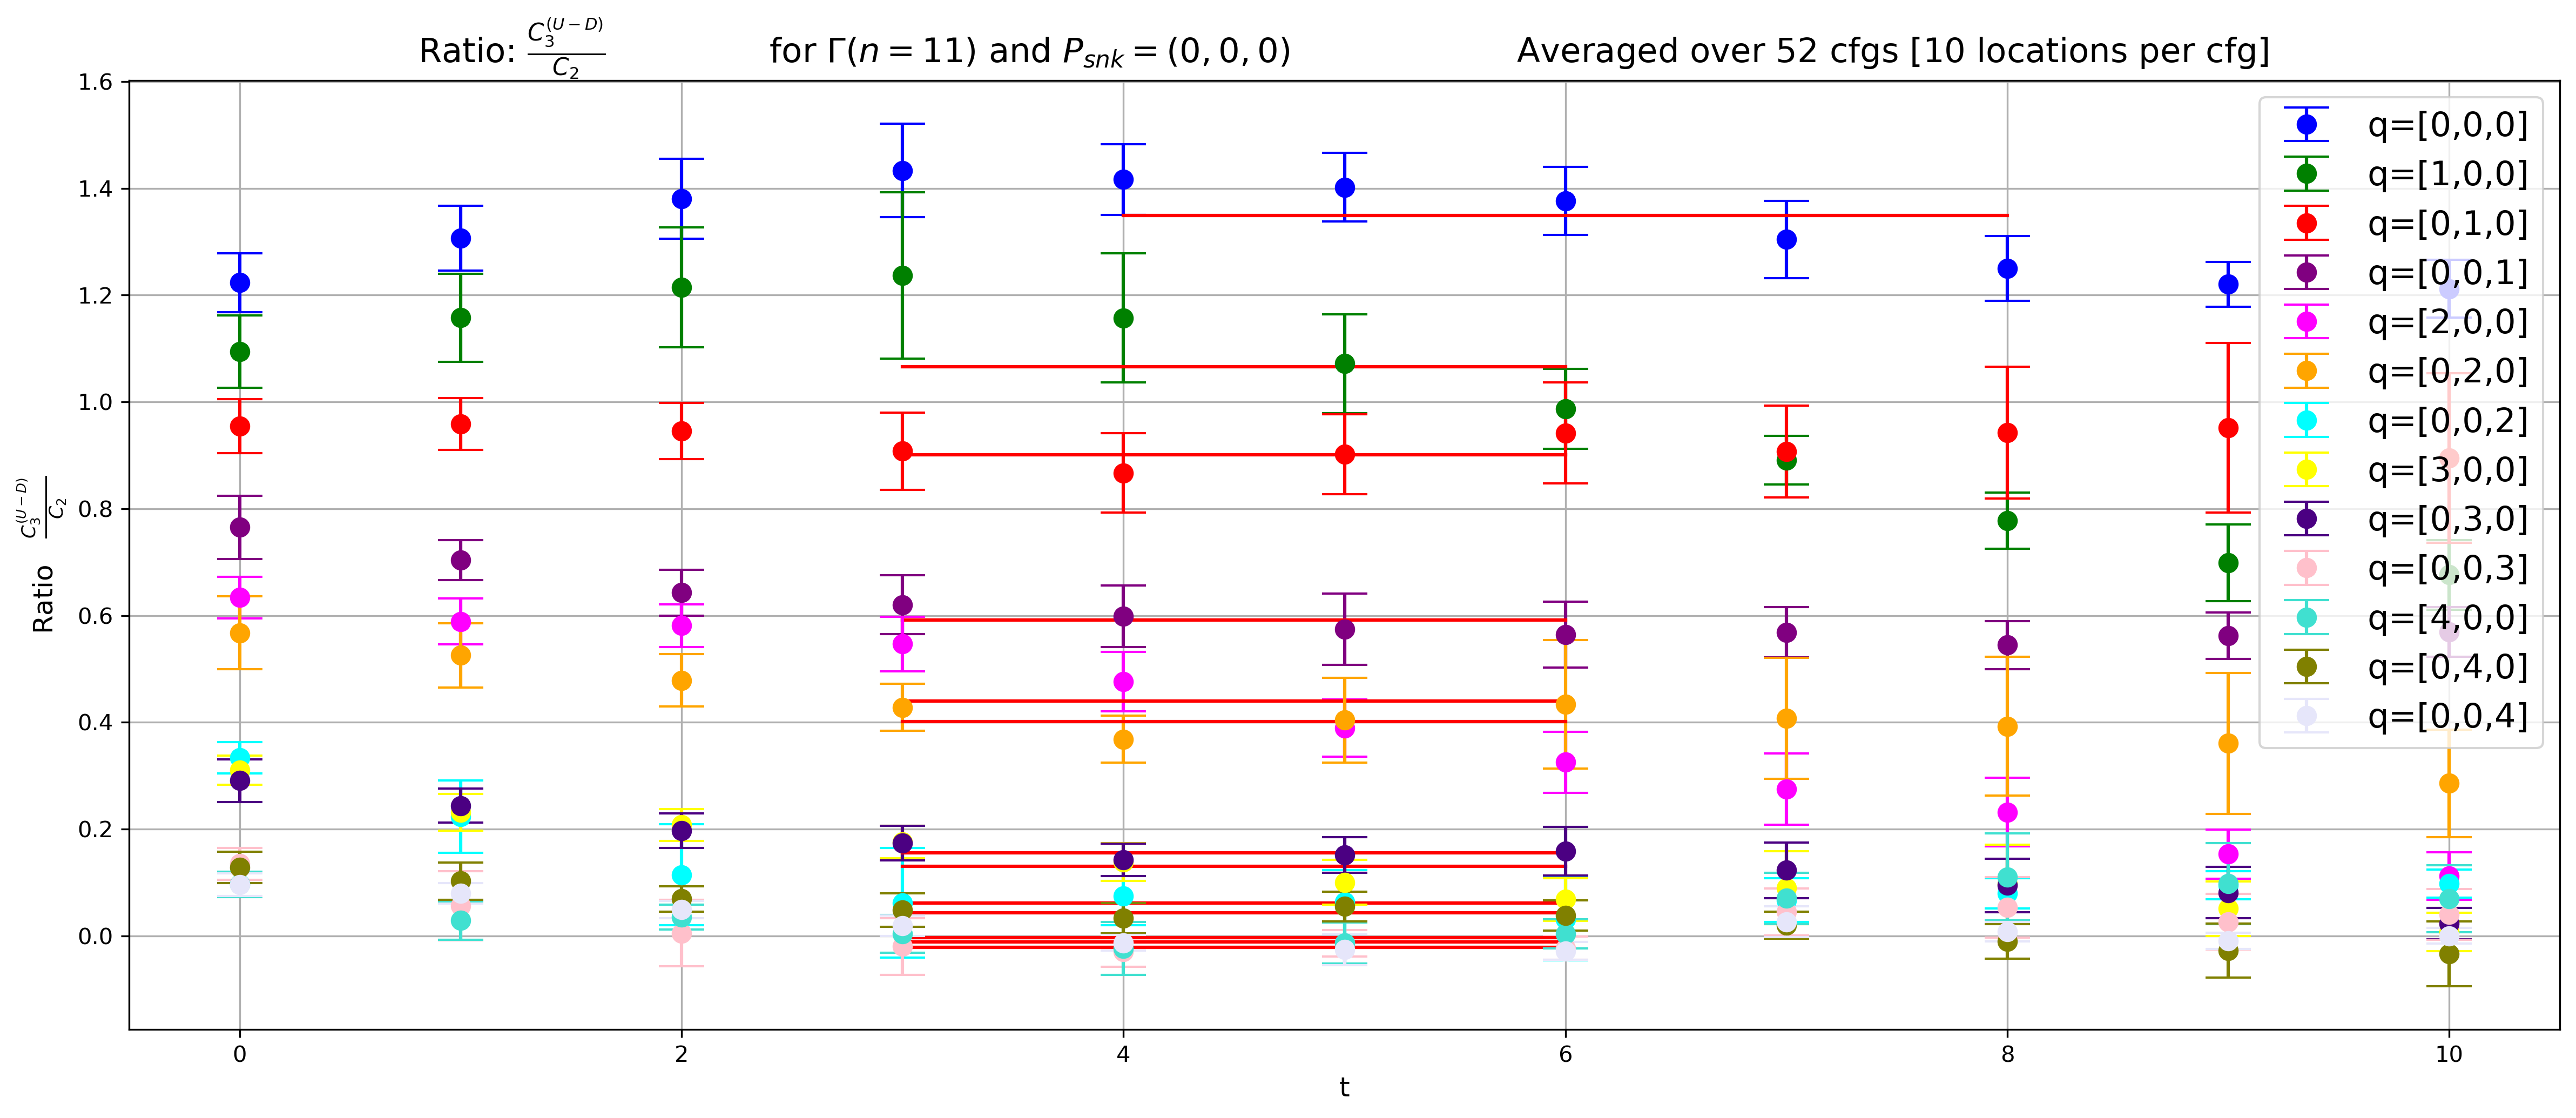

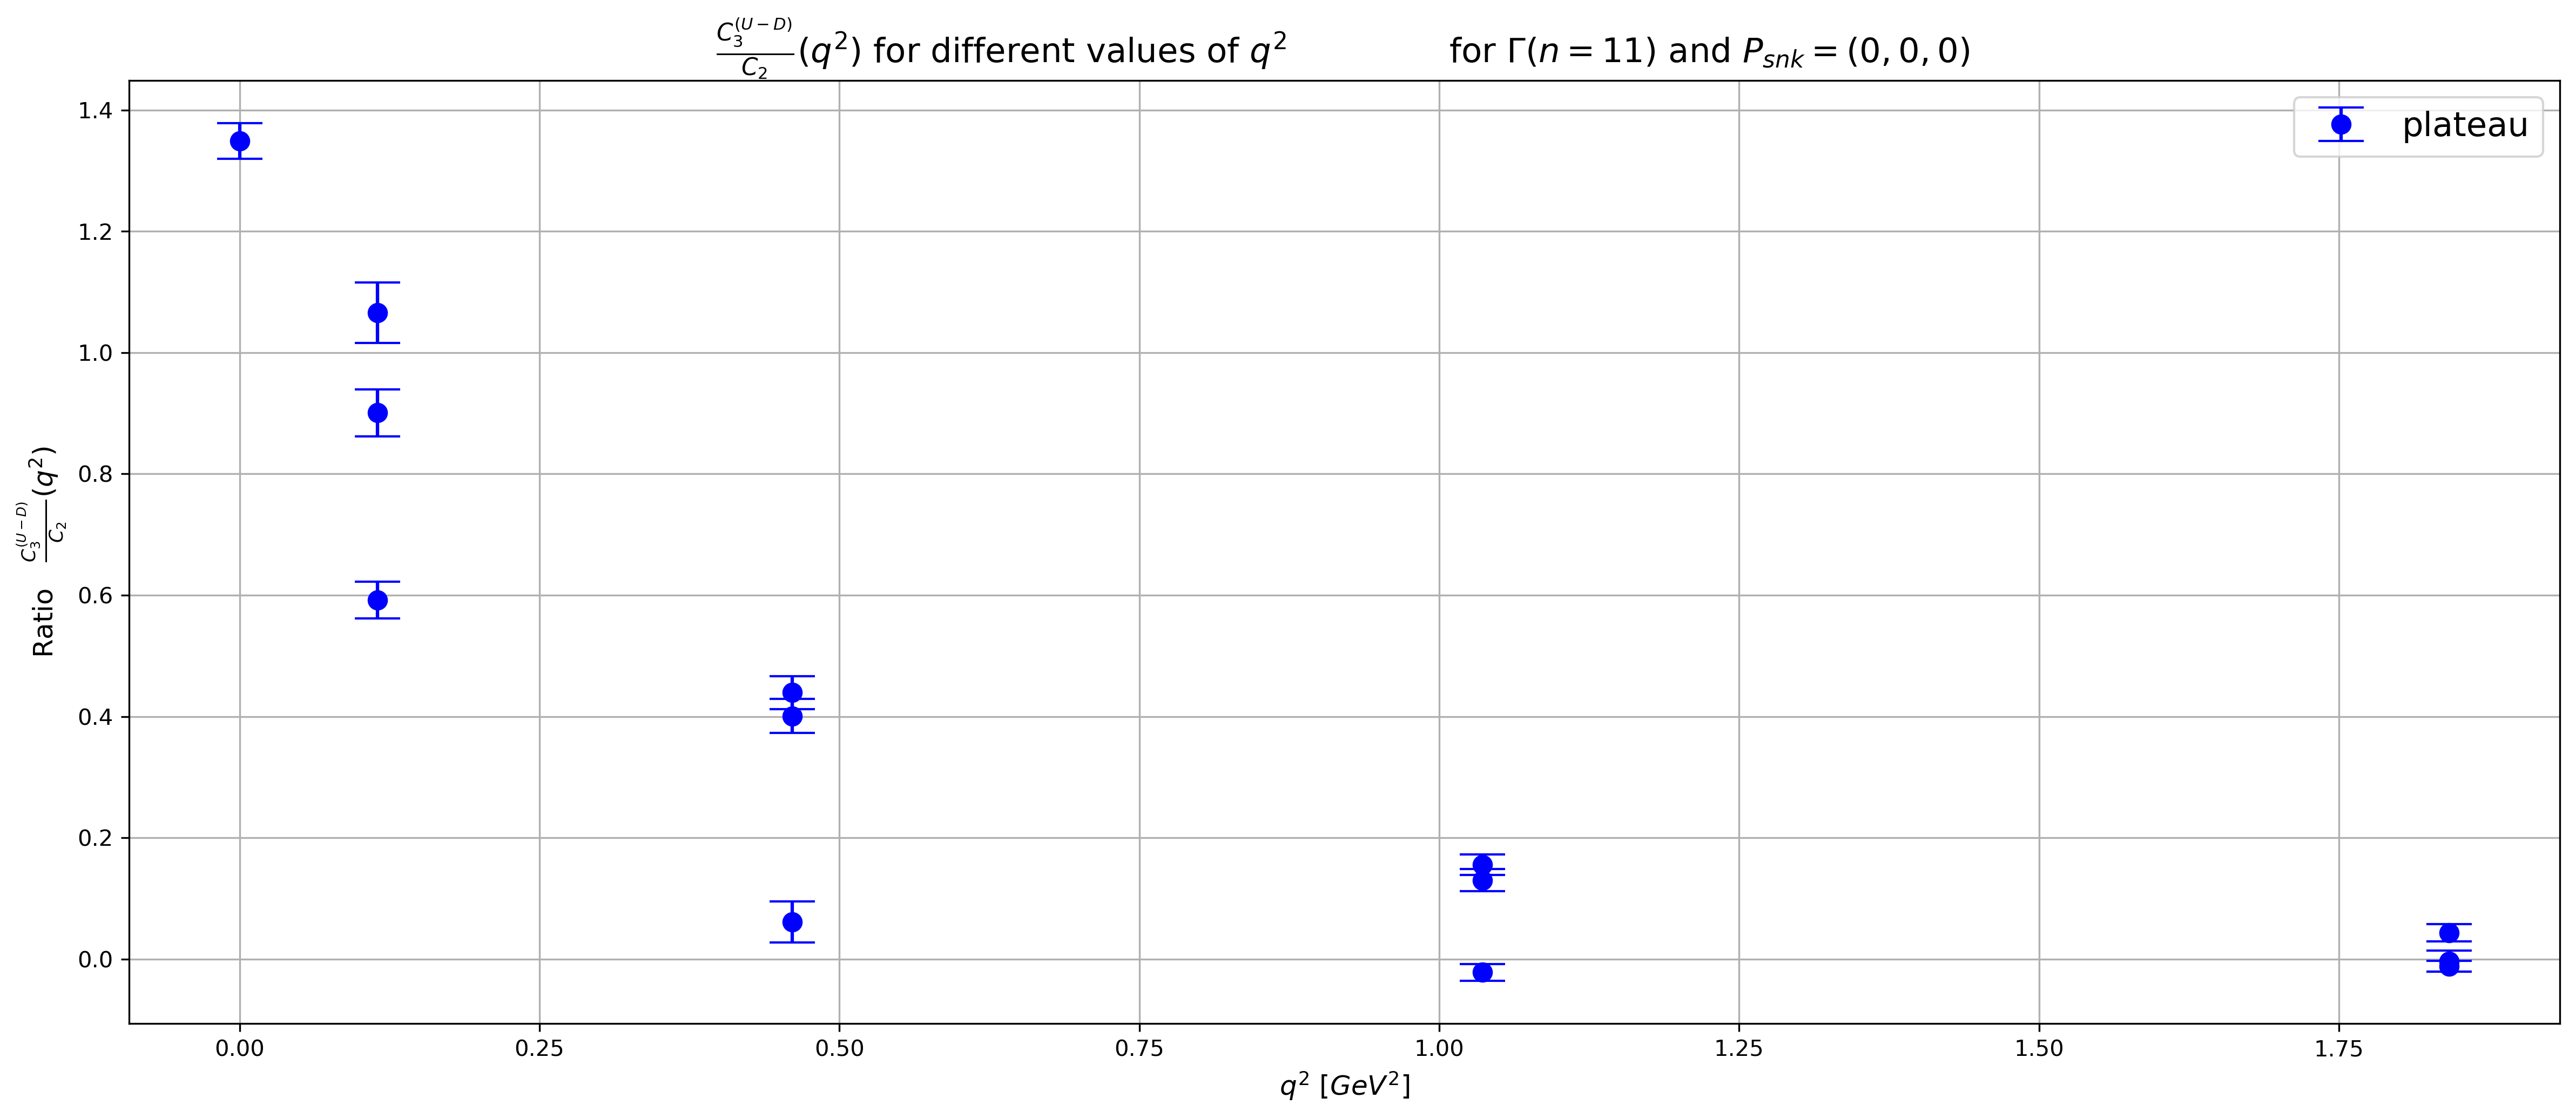

In [5]:
def plot_ratio_3pt_2pt_q(g, q_list, plateau_range):
    plt.subplots(figsize=(16, 7),dpi=300)
    colors = ['blue', 'green', 'red', 'purple', 'magenta', 'orange', 'cyan', 'yellow', 'indigo', 'pink', 'turquoise', 'olive', 'lavender']
    list_ratio_3pt_2pt = []
    list_ratio_3pt_2pt_err = []
    list_q_square = []
    for i, q in enumerate(q_list): 
        q_three = np.square((q[0]*2*np.pi*197)/(a*32))+np.square((q[1]*2*np.pi*197)/(a*32))+np.square((q[2]*2*np.pi*197)/(a*32))
        list_q_square.append(q_three/1000000)
        plateau_t_i, plateau_t_f = plateau_range[i]
        time_for_plot = list(range(0, tsnk+1))
        ratio_3pt_original, error_ratio_3pt_jackknife, x_curve_plateau, y_curve_plateau, ratio_3pt_2pt, ratio_3pt_2pt_err, no_cfgs, sample_per_cfg = jackknife_3pt_ratios(g, q, plateau_t_i, plateau_t_f)
        list_ratio_3pt_2pt.append(ratio_3pt_2pt[0])
        list_ratio_3pt_2pt_err.append(ratio_3pt_2pt_err[0])
        plt.errorbar(time_for_plot, ratio_3pt_original, yerr = error_ratio_3pt_jackknife, fmt='o', markersize=8, capsize=10, color=colors[i], label= 'q=[{},{},{}]'.format(q[0],q[1],q[2]))
        plt.plot(x_curve_plateau, y_curve_plateau, 'r-')
    plt.xlabel("t", fontsize=12)
    plt.ylabel("Ratio   $\\frac{C_3^{(U-D)}}{C_2}$", fontsize=12)
    plt.title("Ratio: $\\frac{C_3^{(U-D)}}{C_2}$               for $\Gamma(n=%d)$ and $P_{snk}=(%d,%d,%d)$                     Averaged over %d cfgs [%d locations per cfg] "%(g, psnk[0], psnk[1], psnk[2], no_cfgs, sample_per_cfg), fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.grid(True) 
    plt.show()
    print("        ")
    plt.subplots(figsize=(16, 7),dpi=300)
    plt.errorbar(list_q_square, list_ratio_3pt_2pt, yerr = list_ratio_3pt_2pt_err, fmt='o', markersize=8, capsize=10, color='blue', label= "plateau")
    plt.ylabel("Ratio   $\\frac{C_3^{(U-D)}}{C_2}(q^{2})$", fontsize=12)
    plt.xlabel("$q^{2}~[GeV^2]$", fontsize=12)
    plt.title("$\\frac{C_3^{(U-D)}}{C_2}(q^{2})$ for different values of $q^{2}$               for $\Gamma(n=%d)$ and $P_{snk}=(%d,%d,%d)$ "%(g, psnk[0], psnk[1], psnk[2]), fontsize=15)
    plt.tight_layout()
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True) 
    plt.show()
    print("        ")
    return

q_list_2 = [[0,0,0,0], [1,0,0,0], [0,1,0,0], [0,0,1,0], [2,0,0,0], [0,2,0,0], [0,0,2,0], [3,0,0,0], [0,3,0,0], [0,0,3,0], [4,0,0,0], [0,4,0,0], [0,0,4,0]]
plateau_range = [[4, 8], [3,6], [3,6], [3,6], [3,6], [3,6], [3,6], [3,6], [3,6], [3,6], [3,6], [3,6], [3,6]]
plot_ratio_3pt_2pt_q(11, q_list_2, plateau_range)